## 3. Empirical Cumulative Outlier Detection (ECOD)

In [1]:
#!pip install pyod
#!pip install statsmodels

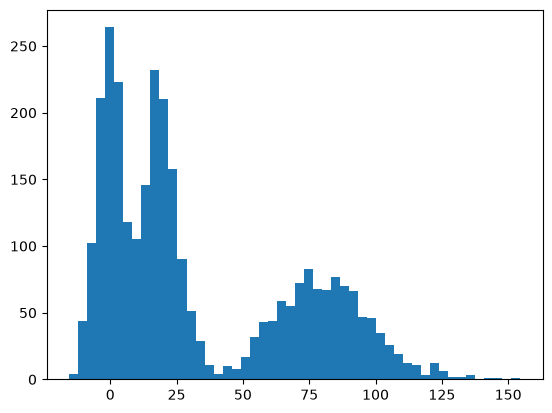

In [13]:
# Create a distribution that is the combination of three other distributions
from matplotlib import pyplot
from numpy.random import normal, gamma
from numpy import hstack
shape, scale = 10, 2.
s1 = gamma(shape, scale, 1000)
s2 = gamma(shape * 2, scale * 2, 1000)
s3 = normal(loc=0, scale=5, size=1000)
sample = hstack((s1, s2, s3))
# plot the histogram
pyplot.hist(sample, bins=50)
pyplot.show()

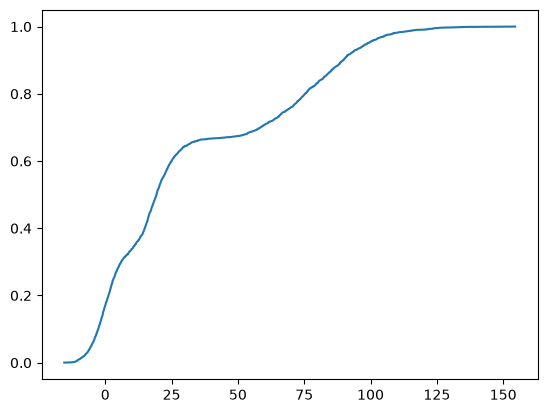

In [14]:
# fit a cdf
from statsmodels.distributions.empirical_distribution import ECDF
sample_ecdf = ECDF(sample)

# plot the cdf
pyplot.plot(sample_ecdf.x, sample_ecdf.y)
pyplot.show()

In [15]:
print('P(x<-20): %.4f' % sample_ecdf(-20))
print('P(x<-2): %.4f' % sample_ecdf(-2))
print('P(x<0): %.4f' % sample_ecdf(0))
print('P(x<25): %.4f' % sample_ecdf(25))
print('P(x<50): %.4f' % sample_ecdf(50))
print('P(x<75): %.4f' % sample_ecdf(75))
print('P(x<100): %.4f' % sample_ecdf(100))
print('P(x<125): %.4f' % sample_ecdf(125))
print('P(x<140): %.4f' % sample_ecdf(140))
print('P(x<150): %.4f' % sample_ecdf(150))

P(x<-20): 0.0000
P(x<-2): 0.1163
P(x<0): 0.1700
P(x<25): 0.5993
P(x<50): 0.6743
P(x<75): 0.7970
P(x<100): 0.9553
P(x<125): 0.9953
P(x<140): 0.9990
P(x<150): 0.9997


In [16]:
######################
# Helper functions
######################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyod.utils.data import generate_data

def DGP(
    contamination=0.05,
    n_train=500,
    n_test=500,
    n_features=6,
    random_state=123,
    shift=True,
    return_df=True
):
    """
    Data Generating Process (DGP) for anomaly detection examples.

    Parameters
    ----------
    contamination : float
        Percentage of outliers
    n_train : int
        Number of training samples
    n_test : int
        Number of test samples
    n_features : int
        Number of features
    random_state : int
        Seed for reproducibility
    shift : bool
        Apply transformation (e.g., 5 - X)
    return_df : bool
        Return pandas DataFrame if True

    Returns
    -------
    X_train, X_test, y_train, y_test
    """

    X_train, X_test, y_train, y_test = generate_data(
        n_train=n_train,
        n_test=n_test,
        n_features=n_features,
        contamination=contamination,
        random_state=random_state
    )

    X_train = 5 - X_train
    X_test = 5 - X_test

    if return_df:
        X_train = pd.DataFrame(X_train)
        X_test = pd.DataFrame(X_test)

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = DGP(
    contamination=0.05,
    n_train=500,
    n_test=500,
    n_features=6,
    random_state=123,
    shift=True,
    return_df=True
)

def plot_generated_data(x1,x2,y_train):
    # Plot
    plt.scatter(x1, x2, c=y_train, alpha=0.8)
    plt.title('Scatter plot')
    plt.xlabel('x0')
    plt.ylabel('x1')
    plt.show()

def evaluate_model(model, X_train, X_test):
    """
    Generate scores, predictions, and threshold for train and test data.

    Parameters
    ----------
    model : trained model
    X_train : array-like
    X_test : array-like

    Returns
    -------
    results : dict
        Contains scores, 
        predictions, and 
        threshold
    """

    results = {
        "train_scores": model.decision_function(X_train),
        "train_pred": model.predict(X_train),
        "test_scores": model.decision_function(X_test),
        "test_pred": model.predict(X_test),
        "threshold": getattr(model, "threshold_", None)
    }

    return results

def count_stat(vector):
    # Because it is '0' and '1', we can run a count statistic.
    unique, counts = np.unique(vector, return_counts=True)
    return dict(zip(unique, counts))

def plot_hist(scores, title="Outlier Score"):
    """
    Plot histogram of outlier scores.

    Parameters
    ----------
    scores : array-like
        Outlier scores
    title : str
        Title of the plot
    """

    plt.hist(scores, bins='auto')
    plt.title(title)
    plt.show()

def descriptive_stat_threshold(X, scores, threshold, feature_names=None):
    """
    Generate descriptive statistics for normal and outlier groups.

    Parameters
    ----------
    X : array-like
        Input data
    scores : array-like
        Outlier scores
    threshold : float
        Threshold to classify outliers
    feature_names : list, optional
        Feature names for labeling columns

    Returns
    -------
    summary : DataFrame
        Count, percentage, and mean statistics by group
    """

    df = pd.DataFrame(X)

    # Assign feature names if provided
    if feature_names:
        df.columns = feature_names

    # Add score and group label
    df["Anomaly_Score"] = scores
    df["Group"] = np.where(df["Anomaly_Score"] < threshold, "Normal", "Outlier")

    # Count and percentage
    count = (
        df.groupby("Group")["Anomaly_Score"]
        .count()
        .reset_index()
        .rename(columns={"Anomaly_Score": "Count"})
    )
    count["Count %"] = count["Count"] / count["Count"].sum() * 100

    # Mean statistics
    stats = (
        df.groupby("Group")
        .mean(numeric_only=True)
        .round(2)
        .reset_index()
    )

    # Merge results
    summary = count.merge(stats, on="Group")

    return summary

def confusion_matrix(actual, scores, threshold):
    """
    Create a confusion matrix using actual labels and outlier scores.

    Parameters
    ----------
    actual : array-like
        True labels (0 = normal, 1 = outlier)
    scores : array-like
        Outlier scores
    threshold : float
        Threshold to classify outliers

    Returns
    -------
    cm : DataFrame
        Confusion matrix
    """

    df = pd.DataFrame({
        "Actual": actual,
        "Score": scores
    })

    # Convert scores to predicted labels
    df["Pred"] = np.where(df["Score"] <= threshold, 0, 1)

    # Generate confusion matrix
    cm = pd.crosstab(df["Actual"], df["Pred"])

    return cm

In [17]:
X_train, X_test, y_train, y_test = DGP(
    contamination=0.05,
    n_train=500,
    n_test=500,
    n_features=6,
    random_state=123,
    shift=True,
    return_df=True
)

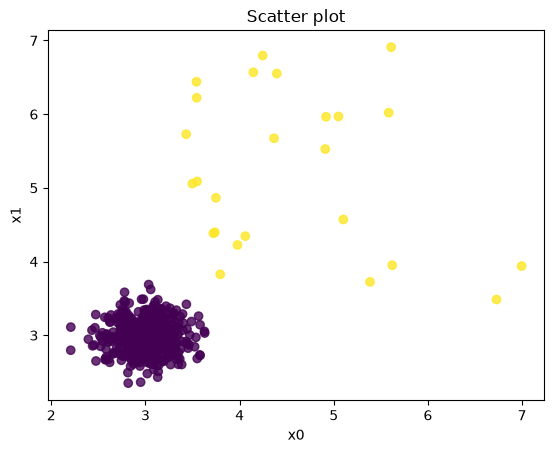

In [18]:
plot_generated_data(X_train[0],X_train[1],y_train)

### Step 1: Build the model

In [19]:
from pyod.models.ecod import ECOD
ecod = ECOD() #contamination=0.05)
ecod.fit(X_train)

,contamination,0.1
,n_jobs,1
Name,Type,Value
decision_scores_,"ndarray[float64](500,)","[10.78,10.23,10.71,...,22.2 ,23.48,23.81]"
labels_,"ndarray[int64](500,)","[0,0,0,...,1,1,1]"
threshold_,float64,12.75


In [20]:
results = evaluate_model(ecod, X_train, X_test)
y_train_scores = results["train_scores"]
y_train_pred = results["train_pred"]

y_test_scores = results["test_scores"]
y_test_pred = results["test_pred"]
threshold = results["threshold"]

In [21]:
# Threshold for the defined comtanimation rate
print("The threshold for the defined contamination rate:" , threshold)
print("The training data:", count_stat(y_train_pred))
print("The test data:", count_stat(y_test_pred))

The threshold for the defined contamination rate: 12.75035460032711
The training data: {np.int64(0): np.int64(450), np.int64(1): np.int64(50)}
The test data: {np.int64(0): np.int64(444), np.int64(1): np.int64(56)}


In [22]:
pick_outliers = np.where(y_train_scores>24)
pick_outliers[0]

array([475, 477, 483, 488, 490])

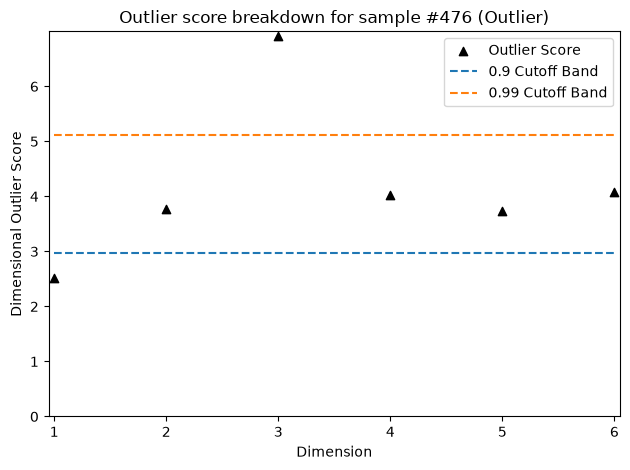

In [23]:
ecod.explain_outlier(pick_outliers[0][0])

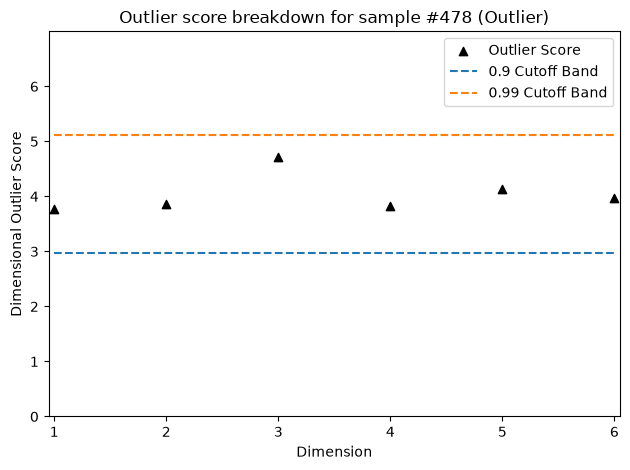

In [24]:
ecod.explain_outlier(pick_outliers[0][1])

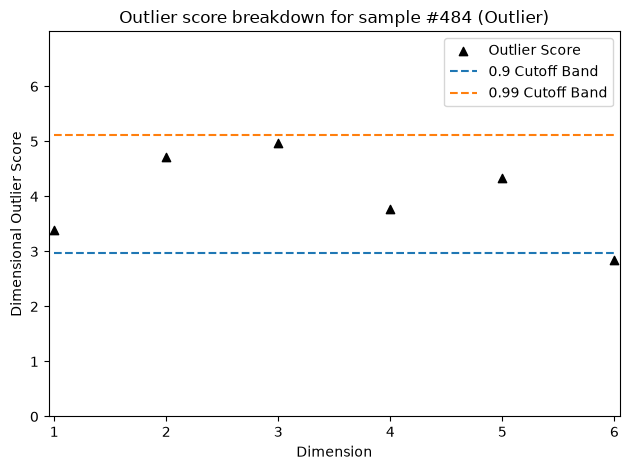

In [25]:
ecod.explain_outlier(pick_outliers[0][2])

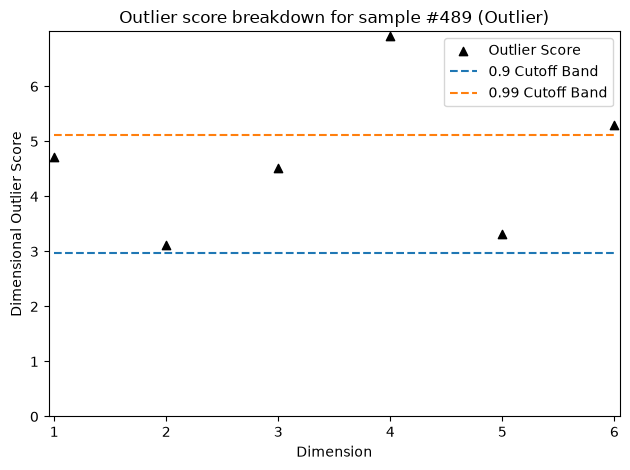

In [26]:
ecod.explain_outlier(pick_outliers[0][3])

### Step 2: Determine the threshold

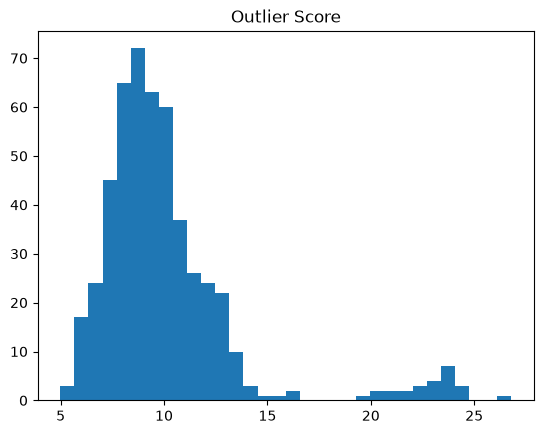

In [27]:
plot_hist(y_train_scores)

### Step 3: Descriptive statistics

In [28]:
feature_list = ['F1','F2','F3','F4','F4','F5']
descriptive_stat_threshold(X_train,y_train_scores, threshold)

,Group,Count,Count %,0,1,2,3,4,5,Anomaly_Score
0,Normal,450,90.0,3.00,3.0,2.99,3.01,3.00,3.02,9.16
1,Outlier,50,10.0,3.74,4.0,4.23,4.10,3.97,3.97,18.28


In [34]:
confusion_matrix(y_test,y_test_scores,threshold)

Pred,0,1
Actual,,
0.0,444,31
1.0,0,25


### Two models: HBOS and ECOD

In [35]:
########
# HBOS #
########
from pyod.models.hbos import HBOS
n_bins = 50
hbos = HBOS(n_bins=n_bins, contamination=0.05)
hbos.fit(X_train)

hbos_results = evaluate_model(hbos, X_train, X_test)
y_train_hbos_scores = hbos_results["train_scores"]
y_train_hbos_pred = hbos_results["train_pred"]

y_test_hbos_scores = hbos_results["test_scores"]
y_test_hbos_pred = hbos_results["test_pred"]
hbos_threshold = hbos_results["threshold"]

########
# ECOD #
########
from pyod.models.ecod import ECOD
clf_name = 'ECOD'
ecod = ECOD(contamination=0.05)
ecod.fit(X_train)

ecod_results = evaluate_model(ecod, X_train, X_test)
y_train_ecod_scores = ecod_results["train_scores"]
y_train_ecod_pred = ecod_results["train_pred"]

y_test_ecod_scores = ecod_results["test_scores"]
y_test_ecod_pred = ecod_results["test_pred"]
ecod_threshold = ecod_results["threshold"]

# Thresholds
[ecod_threshold, hbos_threshold]

[np.float64(16.320821760780653), np.float64(5.563712646460526)]

In [36]:
# Put the actual, the HBO score and the ECOD score together
Actual_pred = pd.DataFrame({'Actual': y_test, 'HBOS_pred': y_test_hbos_pred, 'ECOD_pred': y_test_ecod_pred})
Actual_pred.head()
pd.crosstab(Actual_pred['HBOS_pred'],Actual_pred['ECOD_pred'])

ECOD_pred,0,1
HBOS_pred,,
0,473,1
1,0,26


In [37]:
pd.crosstab(Actual_pred['HBOS_pred'],Actual_pred['ECOD_pred'])

ECOD_pred,0,1
HBOS_pred,,
0,473,1
1,0,26
